<font size="+3.8">Scanpy single-cell pre-processing</font>  
<font size="+1.5">ABC Atlas (Yao 2023 Nature)</font>  


Subset and annotate EC subtypes 

In [ ]:
import json
import os
import re
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse
import seaborn as sns
from matplotlib.pyplot import rc_context

from cellseg_benchmark import BASE_PATH
from cellseg_benchmark.dea_utils import pseudobulk_aggregate_and_filter

In [ ]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

In [ ]:
abc_dir = Path(BASE_PATH) / "misc" / "scRNAseq_ref_ABCAtlas_Yao2023Nature"

# Helper functions

In [17]:
def sort_and_score(adatatemp, marker_genes):
    marker_genes_in_data = {}
    for ct, markers in marker_genes.items():
        markers_found = []
        for marker in markers:
            if marker in adatatemp.var.index:
                markers_found.append(marker)
        if markers_found:
            marker_genes_in_data[ct] = markers_found

    for key in marker_genes_in_data.keys():
        sc.tl.score_genes(adatatemp, marker_genes_in_data[key], score_name=key)

    return adatatemp, marker_genes_in_data

## Merge and preprocess

Cell level adatas subsetted and exported in previous script

In [9]:
setdate = "20250205"  # raw
vasc_v2 = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_merged_v2_vascular_subset.h5ad.gz"
)
vasc_v3 = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_merged_v3_vascular_subset.h5ad.gz"
)

In [10]:
adata = sc.concat([vasc_v2, vasc_v3])
assert adata.shape[0] == vasc_v2.shape[0] + vasc_v3.shape[0]

In [11]:
adata

AnnData object with n_obs × n_vars = 137493 × 32285
    obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'

In [12]:
adata.X.max()

np.float32(11045.0)

In [14]:
adata.layers["counts"] = adata.X.copy()
adata.layers["log1p_norm"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e6, layer="log1p_norm")
sc.pp.log1p(adata, layer="log1p_norm")
adata.X = adata.layers["log1p_norm"]

In [ ]:
adata.layers["zscore"] = sc.pp.scale(
    adata.layers["log1p_norm"], zero_center=True, max_value=None
)

In [ ]:
adata.layers

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3), gridspec_kw={"wspace": 0.4})
titles = ["Counts", "Log-Normalized", "Z-score"]
for ax, data, bins, title in zip(
    axs,
    [
        adata.layers["counts"].sum(1),
        adata.layers["log1p_norm"].sum(1),
        adata.layers["zscore"].sum(1),
    ],
    [100, 100, 100],
    titles,
):
    sns.histplot(data, kde=False, bins=bins, ax=ax, zorder=2, alpha=1)
    ax.set_title(title)
    ax.grid(True)
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    for patch in ax.patches:
        patch.set_edgecolor("none")
plt.show()

In [ ]:
adata.X = adata.layers["zscore"]

In [ ]:
sc.pp.highly_variable_genes(
    adata, n_top_genes=4000, batch_key="library_method", layer="log1p_norm"
)
sc.pl.highly_variable_genes(adata)

In [ ]:
sc.tl.pca(adata)

In [ ]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

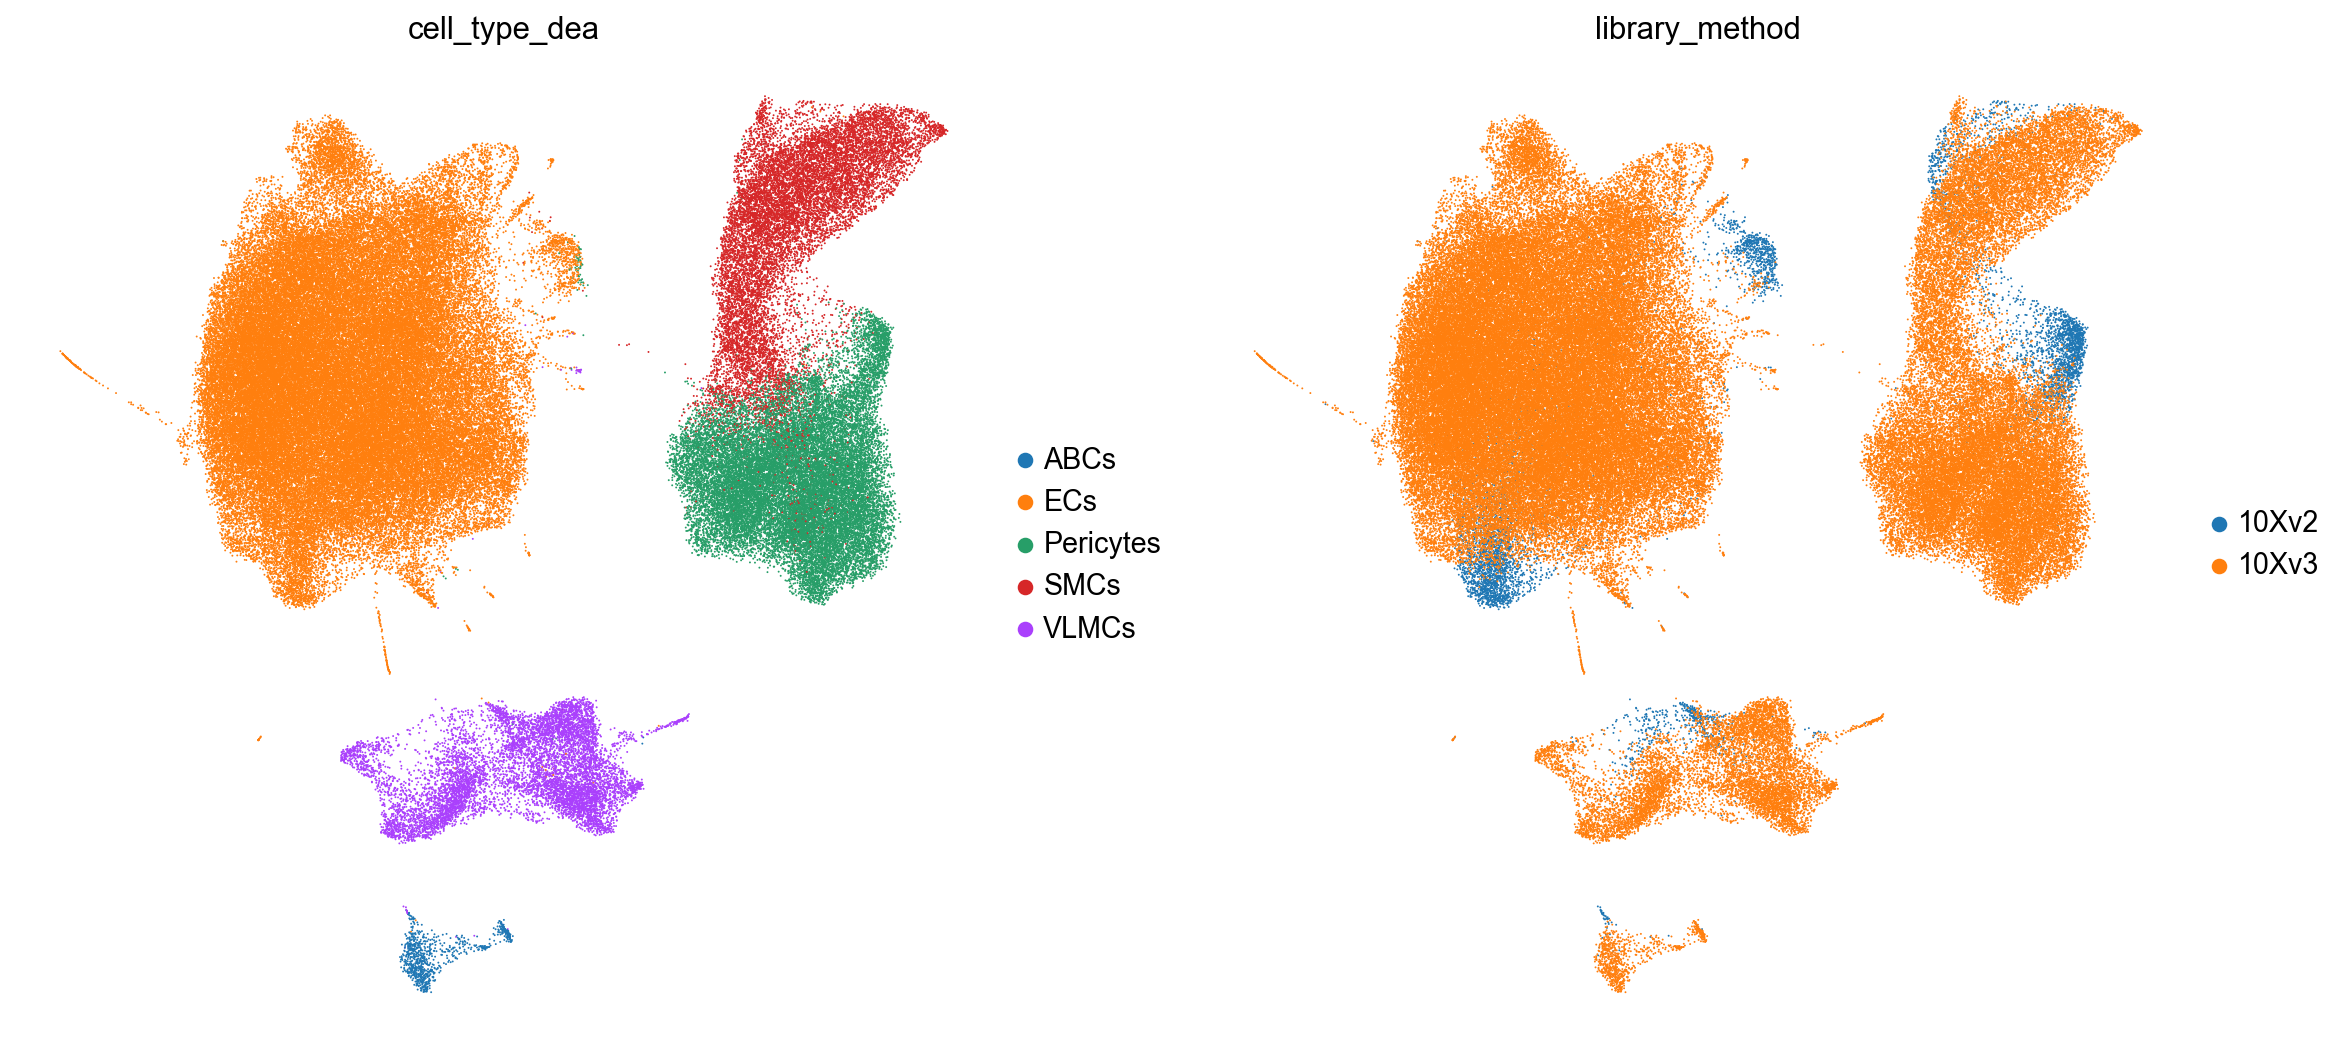

In [23]:
with rc_context({"figure.figsize": (8, 8)}):
    sc.pl.umap(
        adata,
        color=["cell_type_dea", "library_method"],
        size=3,
    )

In [24]:
adata.obsm["X_umap_unintegrated"] = adata.obsm["X_umap"].copy()
adata.obsm["X_pca_unintegrated"] = adata.obsm["X_pca"].copy()

In [25]:
del adata.uns["pca"]
del adata.obsm["X_pca"]
del adata.uns["neighbors"]
del adata.obsp["distances"]
del adata.obsp["connectivities"]
del adata.uns["umap"]
del adata.obsm["X_umap"]

## Integrate

In [26]:
adata.X = adata.layers["zscore"]

In [27]:
sc.tl.pca(adata)

In [28]:
%%time
sc.external.pp.harmony_integrate(adata, key="library_method")

2025-02-05 14:24:00,597 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-02-05 15:24:45,295 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-02-05 15:24:45,610 - harmonypy - INFO - Iteration 1 of 10
2025-02-05 15:25:31,338 - harmonypy - INFO - Iteration 2 of 10
2025-02-05 15:26:05,409 - harmonypy - INFO - Converged after 2 iterations


CPU times: user 9h 23s, sys: 25min 51s, total: 9h 26min 14s
Wall time: 1h 2min 4s


In [29]:
%%time
sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_pcs=50)
sc.tl.umap(adata)

CPU times: user 1min 28s, sys: 20.6 s, total: 1min 49s
Wall time: 1min 2s


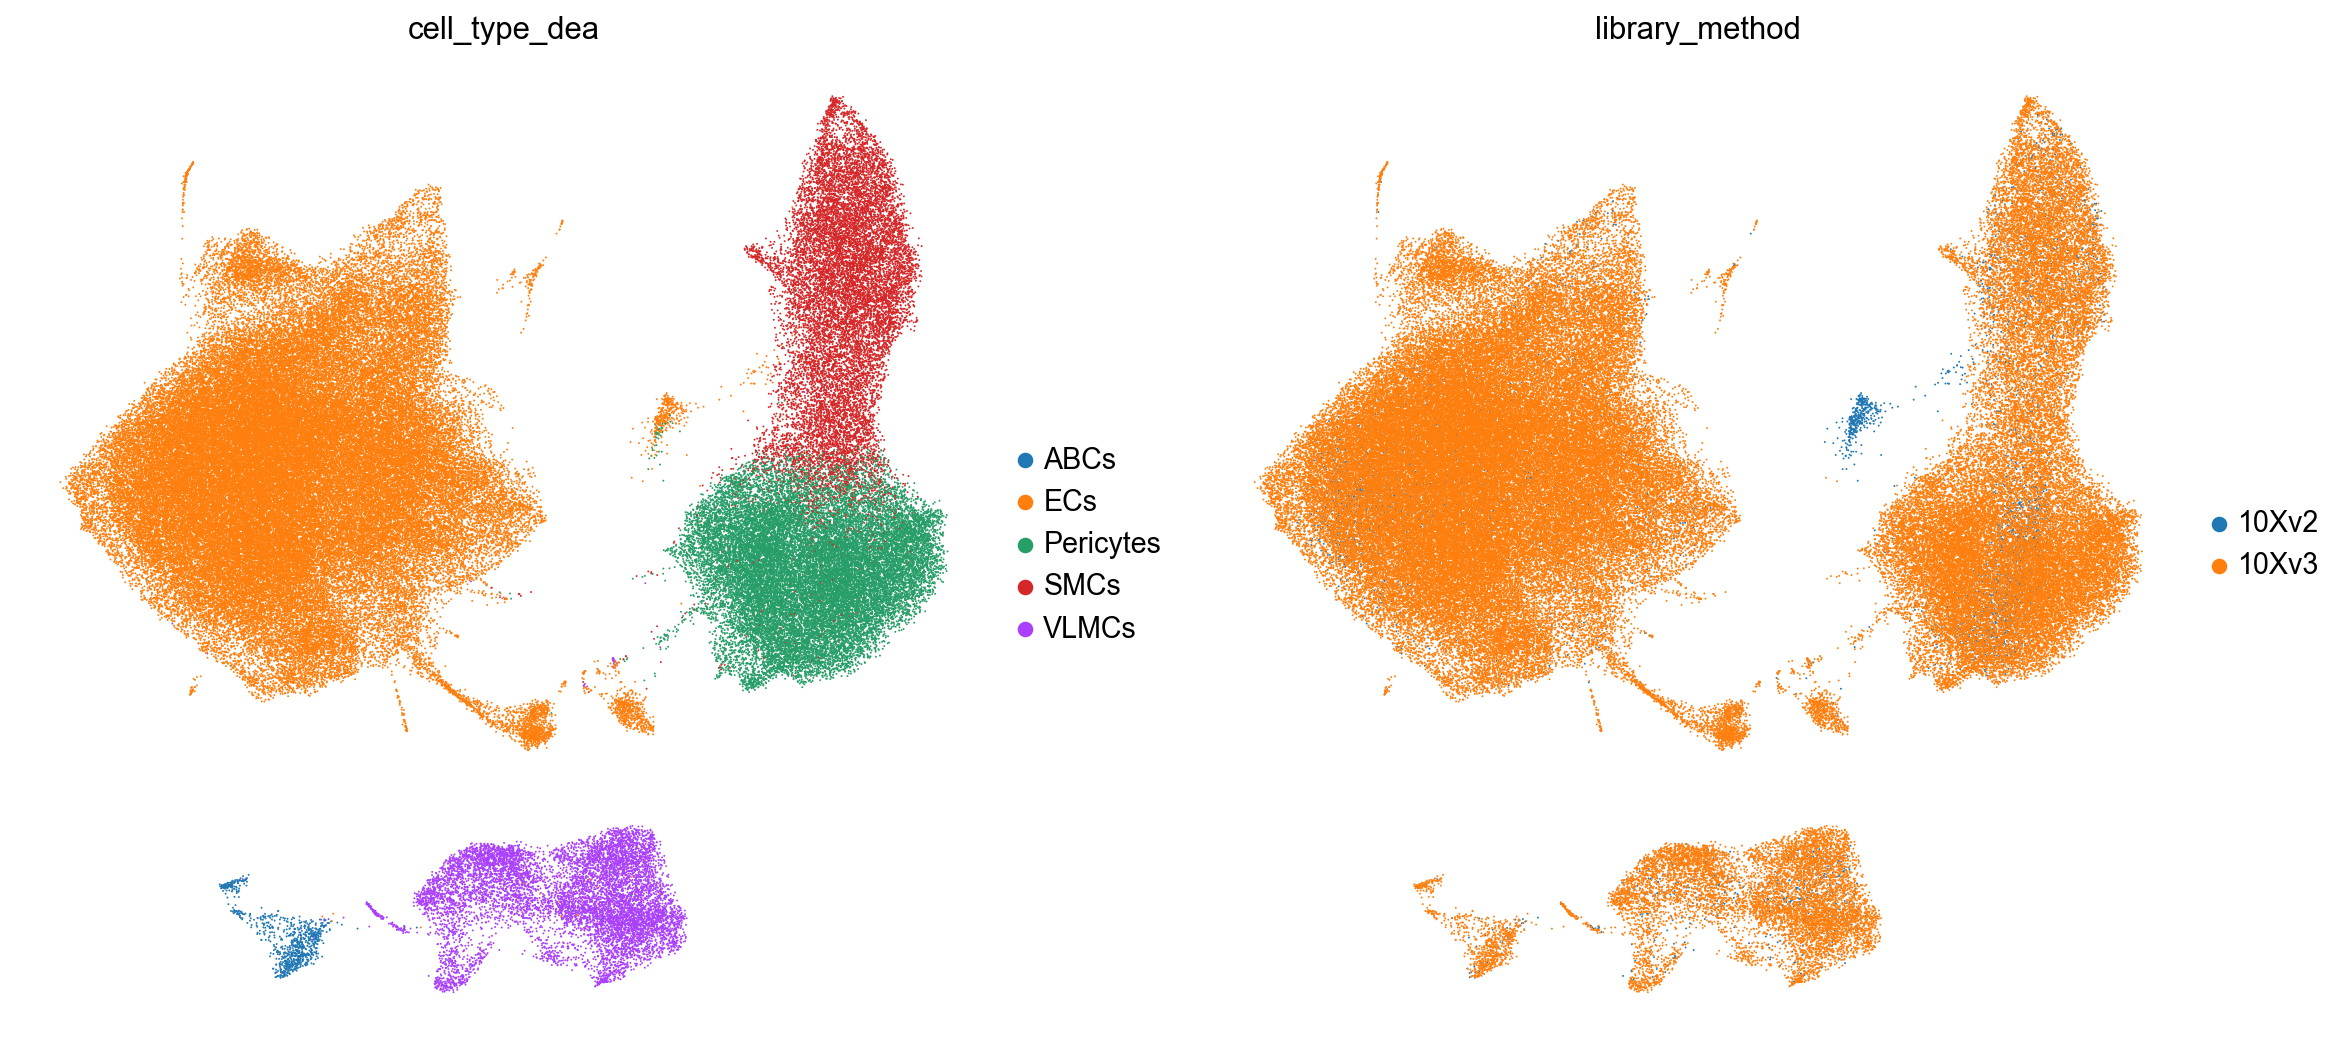

In [30]:
with rc_context({"figure.figsize": (8, 8)}):
    sc.pl.umap(
        adata,
        color=["cell_type_dea", "library_method"],
        size=3,
    )

## Cluster

In [31]:
resolutions = [0.05, 0.1, 0.2, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
for res in resolutions:
    sc.tl.leiden(adata, key_added=f"leiden_res{res}".replace(".", "_"), resolution=res)

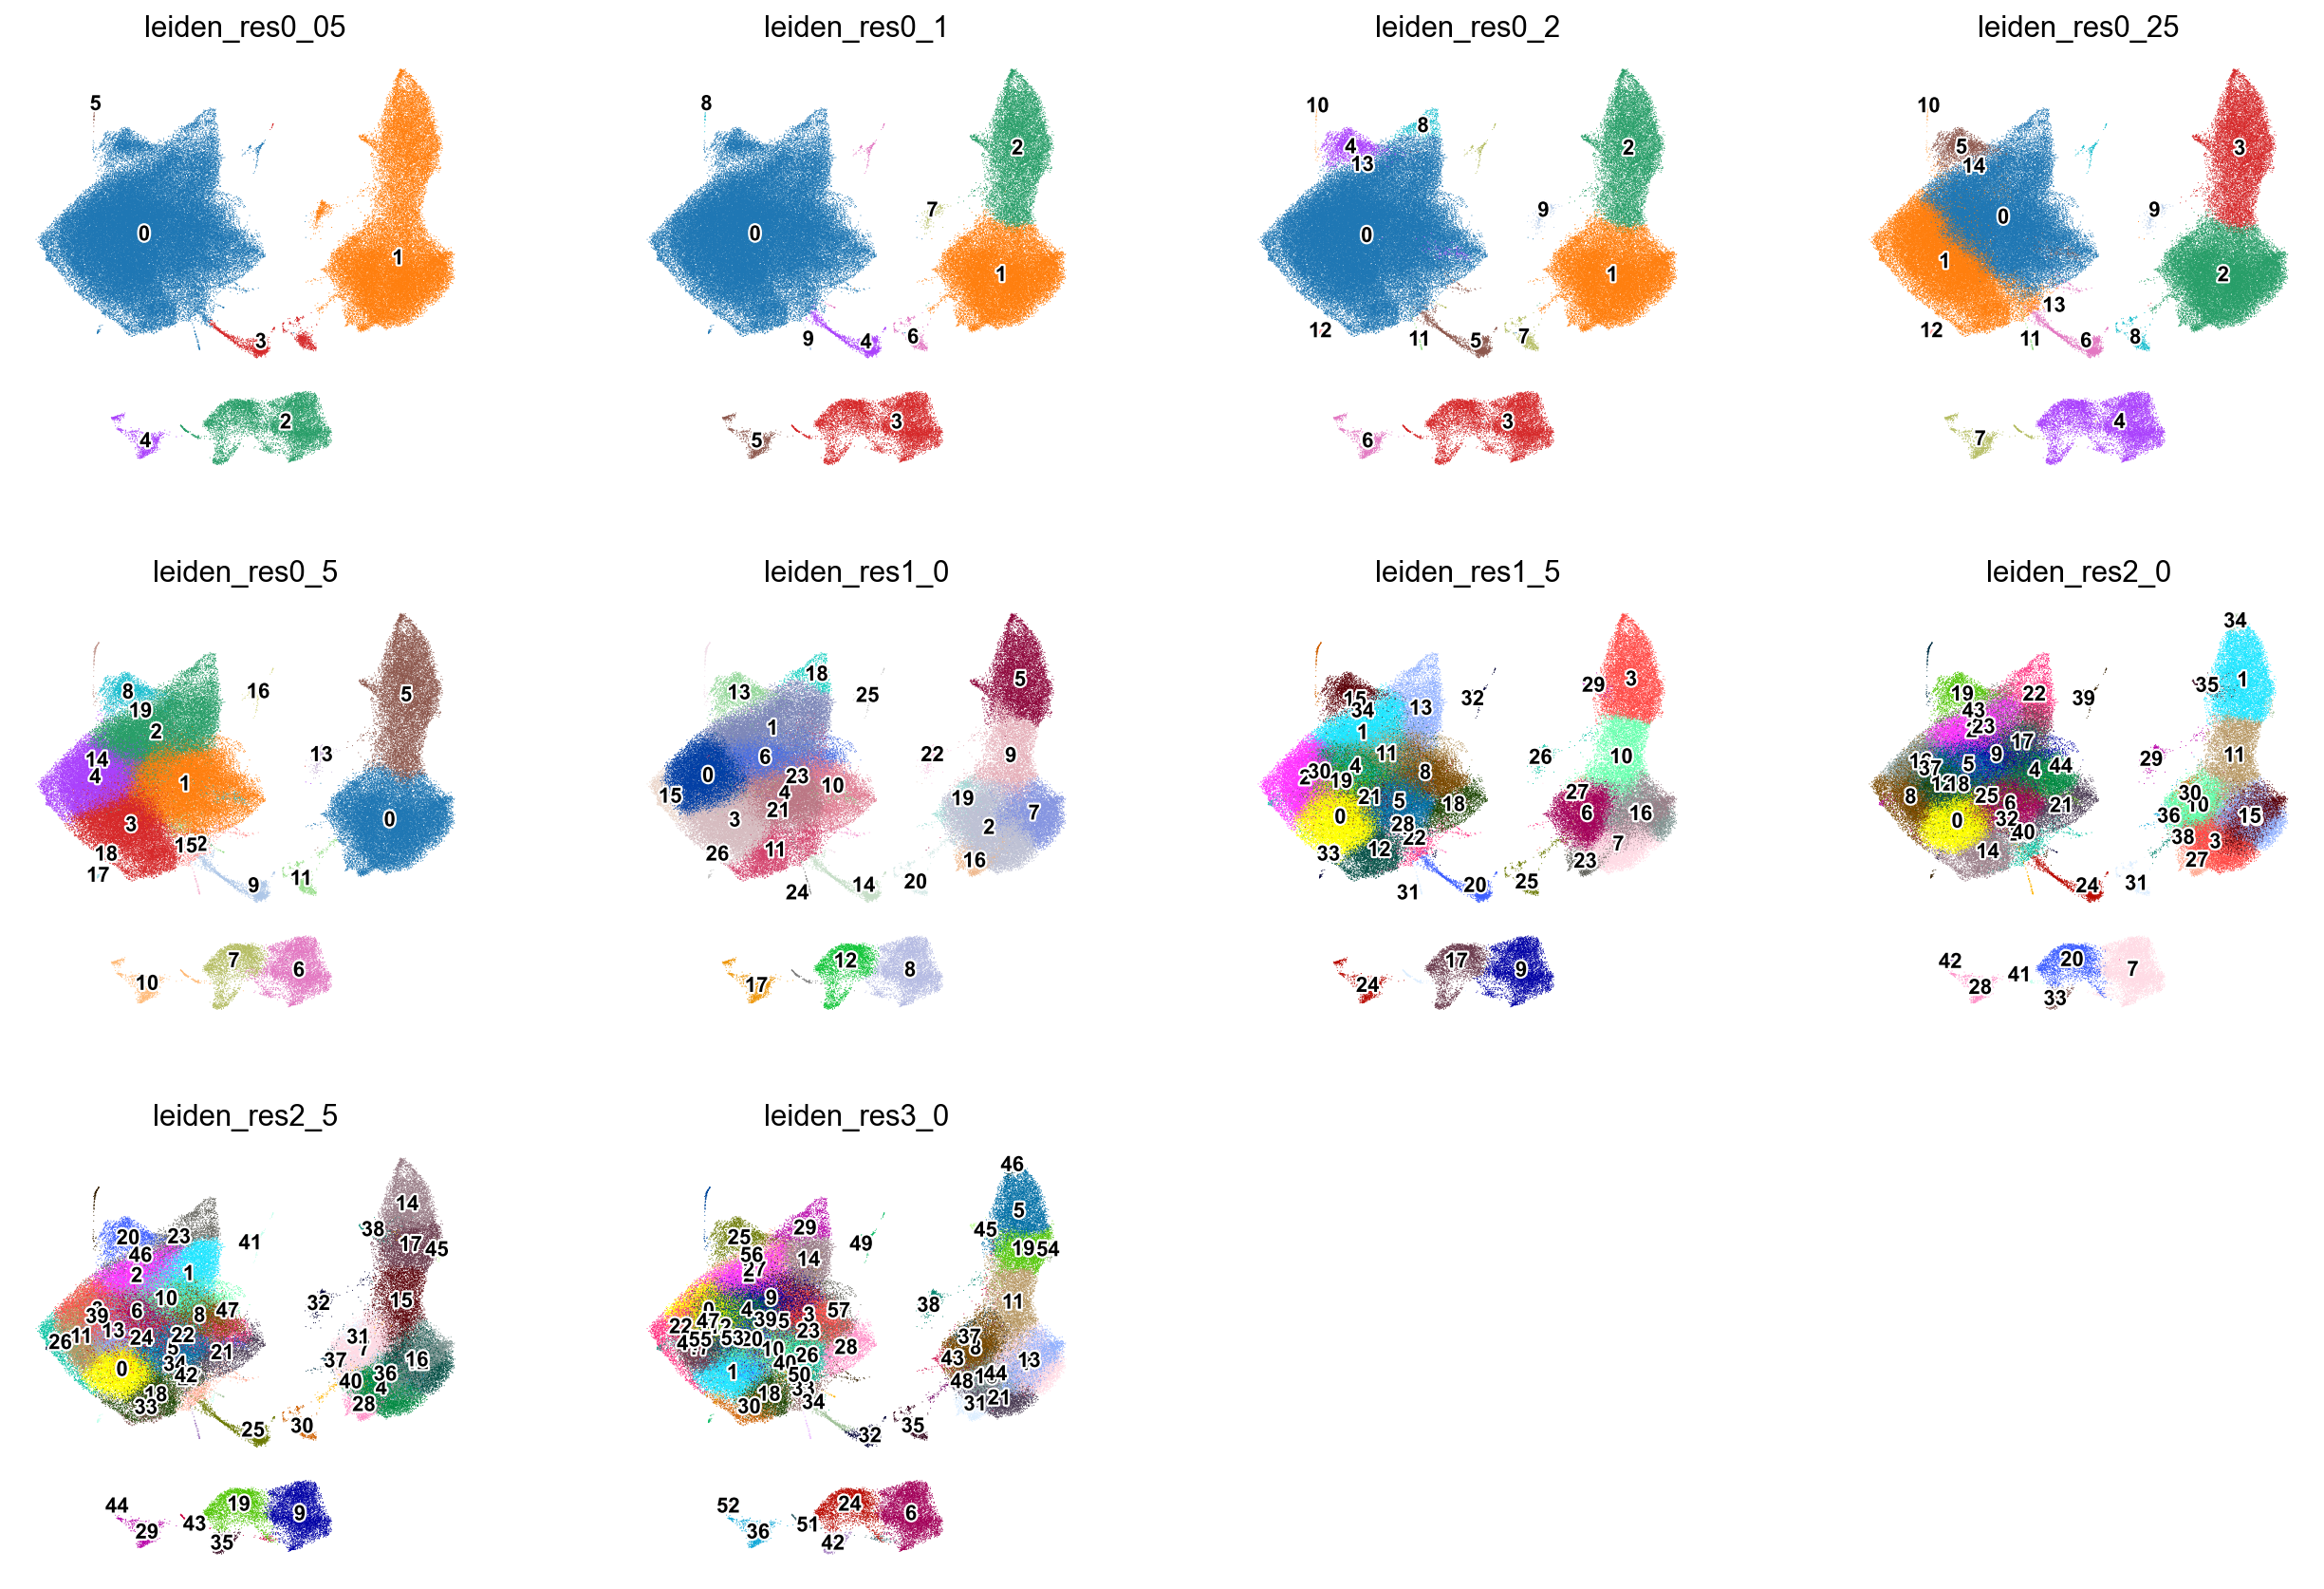

In [32]:
color_keys = [f"leiden_res{res}".replace(".", "_") for res in resolutions]
sc.pl.umap(
    adata,
    color=color_keys,
    legend_loc="on data",
    ncols=4,
    legend_fontoutline=2,
    legend_fontsize=10,
)

In [49]:
res = 1.0
res = f"leiden_res{res}".replace(".", "_")

## Save/Load

In [12]:
name = "ABCAtlas_vascular_integrated"

In [36]:
adata.write(
    abc_dir / "anndata-objects" / f"{date.today():%Y%m%d}_{name}.h5ad.gz",
    compression="gzip",
)

In [37]:
adata.shape

(137493, 32285)

In [13]:
setdate = "20250205"
x = os.listdir(abc_dir / "anndata-objects")
pattern = re.compile(setdate + "_" + name + r".*\.h5ad\.gz$")
x = [val for val in x if pattern.match(val)]
x

['20250205_ABCAtlas_vascular_integrated.h5ad.gz']

In [14]:
adata = sc.read_h5ad(abc_dir / "anndata-objects" / x[0])

In [ ]:
adata

## Marker genes

In [18]:
cell_cyle_genes = {
    "G1": ["Ccne1", "Pttg1"],
    "G1_S": ["Slbp", "Cdca7", "Ung", "Cdc6", "Pcna", "Mcm5", "Orc1", "Dtl"],
    "S": ["Rrm2", "E2f8", "Atad2"],
    "G2": ["Ccnf", "Cdca8", "Hjurp", "Cdk1", "Top2a", "Kif23"],
    "G2_M": ["Kpna2", "Bub1b", "Tacc3"],
    "M": ["Plk1", "Mapk13", "Aurka", "Tpx2"],
    "Proliferation": ["Mki67"],
}

In [71]:
marker_path = abc_dir / "marker_genes_manual"
files = [
    "merfish_cell_supertypes.json",
    "merfish_cell_types.json",
    "merfish_EC_subtypes.json",
    "merfish_vascular_subtypes_nonEC.json",
]
marker_dicts = {}
for file in files:
    with open(marker_path / file, "r") as f:
        marker_dicts[file.split(".")[0]] = json.load(f)

In [ ]:
list(marker_dicts.keys())

In [23]:
adatatemp = adata

Plot and export

In [24]:
samplename = "ABCAtlas_vasc_subset"

In [26]:
output_dir_plots = abc_dir / "zonation_annotation/plots_marker_genes"
output_dir_plots.mkdir(parents=True, exist_ok=True)

### Cell cycle

Score groups:

In [54]:
adatatemp, marker_genes_in_data = sort_and_score(adatatemp, cell_cyle_genes)

In [55]:
name = "cell_cycle"

In [57]:
with rc_context({"figure.figsize": (6, 6)}):
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data.keys(),
        frameon=False,
        ncols=3,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=0.7,
        sort_order=True,
        show=False,
    )
plt.savefig(
    f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_scores.png",
    bbox_inches="tight",
)
plt.close()

Individual marker genes:

In [58]:
os.makedirs(f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes")
for ct in marker_genes_in_data:
    print(f"{ct.upper()}")
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data[ct],
        frameon=False,
        ncols=3,
        vmin=0,
        vmax="p99",
        sort_order=True,
        cmap="Reds",
        show=False,
    )
    plt.savefig(
        f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes/{ct}.png",
        bbox_inches="tight",
    )
    plt.close()

G1
G1_S
S
G2
G2_M
M
PROLIFERATION


### Cell types

Score groups:

#### Cell Supertypes
From MERFISH gene panel google sheet

In [27]:
adatatemp, marker_genes_in_data = sort_and_score(
    adatatemp, marker_dicts["merfish_cell_supertypes"]
)

In [28]:
name = "cell_supertypes"

In [30]:
with rc_context({"figure.figsize": (6, 6)}):
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data.keys(),
        frameon=False,
        ncols=3,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=0.8,
        sort_order=True,
        show=False,
    )
plt.savefig(
    f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_scores.png",
    bbox_inches="tight",
)
plt.close()

#### Cell Types
From MERFISH gene panel google sheet

In [31]:
adatatemp, marker_genes_in_data = sort_and_score(
    adatatemp, marker_dicts["merfish_cell_types"]
)

In [32]:
name = "cell_types"

In [33]:
with rc_context({"figure.figsize": (6, 6)}):
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data.keys(),
        frameon=False,
        ncols=3,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=0.9,
        sort_order=True,
        show=False,
    )
plt.savefig(
    f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_scores.png",
    bbox_inches="tight",
)
plt.close()

Individual marker genes:

In [ ]:
os.makedirs(f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes")
for ct in marker_genes_in_data:
    print(f"{ct.upper()}")
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data[ct],
        frameon=False,
        ncols=3,
        vmin=0,
        vmax="p99",
        sort_order=True,
        cmap="Reds",
        show=False,
    )
    plt.savefig(
        f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes/{ct}.png",
        bbox_inches="tight",
    )
    plt.close()

#### EC Cell Subtypes
(merfish_panel_500_mouse_brain)

In [34]:
adatatemp, marker_genes_in_data = sort_and_score(
    adatatemp, marker_dicts["merfish_EC_subtypes"]
)

In [35]:
name = "EC_subtypes"

In [36]:
with rc_context({"figure.figsize": (6, 6)}):
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data.keys(),
        frameon=False,
        ncols=3,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=0.9,
        sort_order=True,
        show=False,
    )
plt.savefig(
    f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_scores.png",
    bbox_inches="tight",
)
plt.close()

Individual marker genes:

In [37]:
os.makedirs(f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes")
for ct in marker_genes_in_data:
    print(f"{ct.upper()}")
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data[ct],
        frameon=False,
        ncols=3,
        vmin=0,
        vmax="p99",
        sort_order=True,
        cmap="Reds",
        show=False,
    )
    plt.savefig(
        f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes/{ct}.png",
        bbox_inches="tight",
    )
    plt.close()

PAN-EC
LARGE ARTERY ECS
AECS
CAPILLARY-ARTERIAL ECS
CAPECS
CAPILLARY-VENOUS ECS
POST-CAPILLARY VENULES
VECS
LARGE VEIN ECS
ARTERIAL-VENOUS_LARGE-VESSEL ECS
AD PATHOLOGY IN BEC AGING
OXIDATIVE STRESS BEC
INTERFERON-ACTIVATED ECS
SHEAR STRESS ARTERIAL ECS
INFLAMMATORY VASCULATURE (ECS)
PRO-ANGIOGENIC ARTERIOLAR ECS
UPREGULATED IN PERICYTE-DEFICIENT MICE (ECS)
EXP LOST IN PERICYTE-DEFICIENT MICE (ECS)
EXP LOST IN MICROVESSEL BUT NOT LARGER VESSELS (VEINS) OF PERICYTE-DEFICIENT MICE (ECS)
ANGIOGENIC ECS
UPREGULATED AT BBB LEAKAGE SITE (ECS)
TRANSFORMED ECS IN PERICYTE-DEFICIENT MICE
UPREGULATED IN AGED ECS
ENDO-3 (ENRICHED IN OLD MICE)
TIP ECS
MIGHT REFLECT ENDOTHELIAL CELL-MICROGLIA COMMUNICATION IN INFLAMMATORY PROCESSES
CHOROID PLEXUS ECS


#### Other vascular Subtypes
(merfish_panel_500_mouse_brain)

In [ ]:
adatatemp, marker_genes_in_data = sort_and_score(
    adatatemp, marker_dicts["merfish_vascular_subtypes_nonEC"]
)

In [ ]:
name = "other_vascular_subtypes"

In [ ]:
with rc_context({"figure.figsize": (6, 6)}):
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data.keys(),
        frameon=False,
        ncols=3,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=0.9,
        sort_order=True,
        show=False,
    )
plt.savefig(
    f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_scores.png",
    bbox_inches="tight",
)
plt.close()

Individual marker genes:

In [ ]:
os.makedirs(f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes")
for ct in marker_genes_in_data:
    print(f"{ct.upper()}")
    sc.pl.umap(
        adatatemp,
        color=marker_genes_in_data[ct],
        frameon=False,
        ncols=3,
        vmin=0,
        vmax="p99",
        sort_order=True,
        cmap="Reds",
        show=False,
    )
    plt.savefig(
        f"{output_dir_plots}/{date.today():%Y%m%d}_{samplename}_{name}_UMAP_genes/{ct}.png",
        bbox_inches="tight",
    )
    plt.close()

In [44]:
del adatatemp

## Annotate

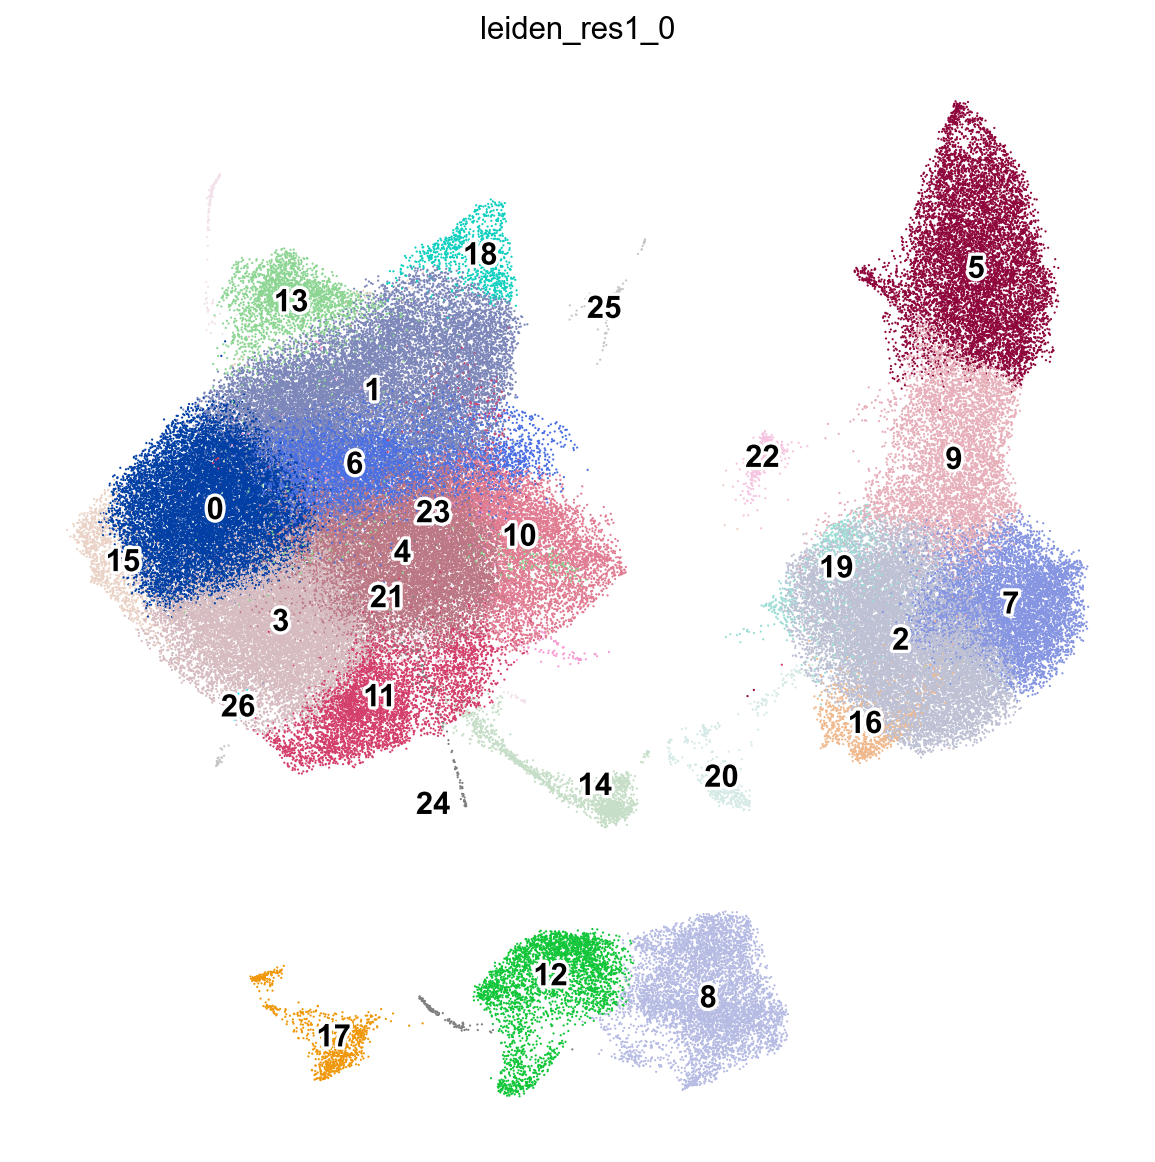

In [34]:
with rc_context({"figure.figsize": (9, 9)}):
    sc.pl.umap(adata, color=res, legend_loc="on data", size=4, legend_fontoutline=3)

In [80]:
adata.obs["cell_type_dea_previous"] = adata.obs["cell_type_dea"].copy()

In [81]:
old_to_new = {
    "0": "capECs",
    "1": "aECs",
    "2": "Pericytes",
    "3": "capECs",
    "4": "vECs",
    "5": "SMCs",
    "6": "capECs",
    "7": "Pericytes",
    "8": "VLMCs",
    "9": "SMCs-Pericytes",
    "10": "vECs",
    "11": "capECs",
    "12": "VLMCs",
    "13": "capECs",
    "14": "ECs-Astro",
    "15": "capECs",
    "16": "Pericytes",
    "17": "ABCs",
    "18": "aECs",
    "19": "Pericytes",
    "20": "ECs-Immune",
    "21": "capECs",
    "22": "ECs-Pericytes",
    "23": "capECs",
    "24": "ECs-Other",
    "25": "capECs",
    "26": "capECs",
}

In [82]:
adata.obs["cell_type_dea"] = adata.obs[res].map(old_to_new).astype("category")

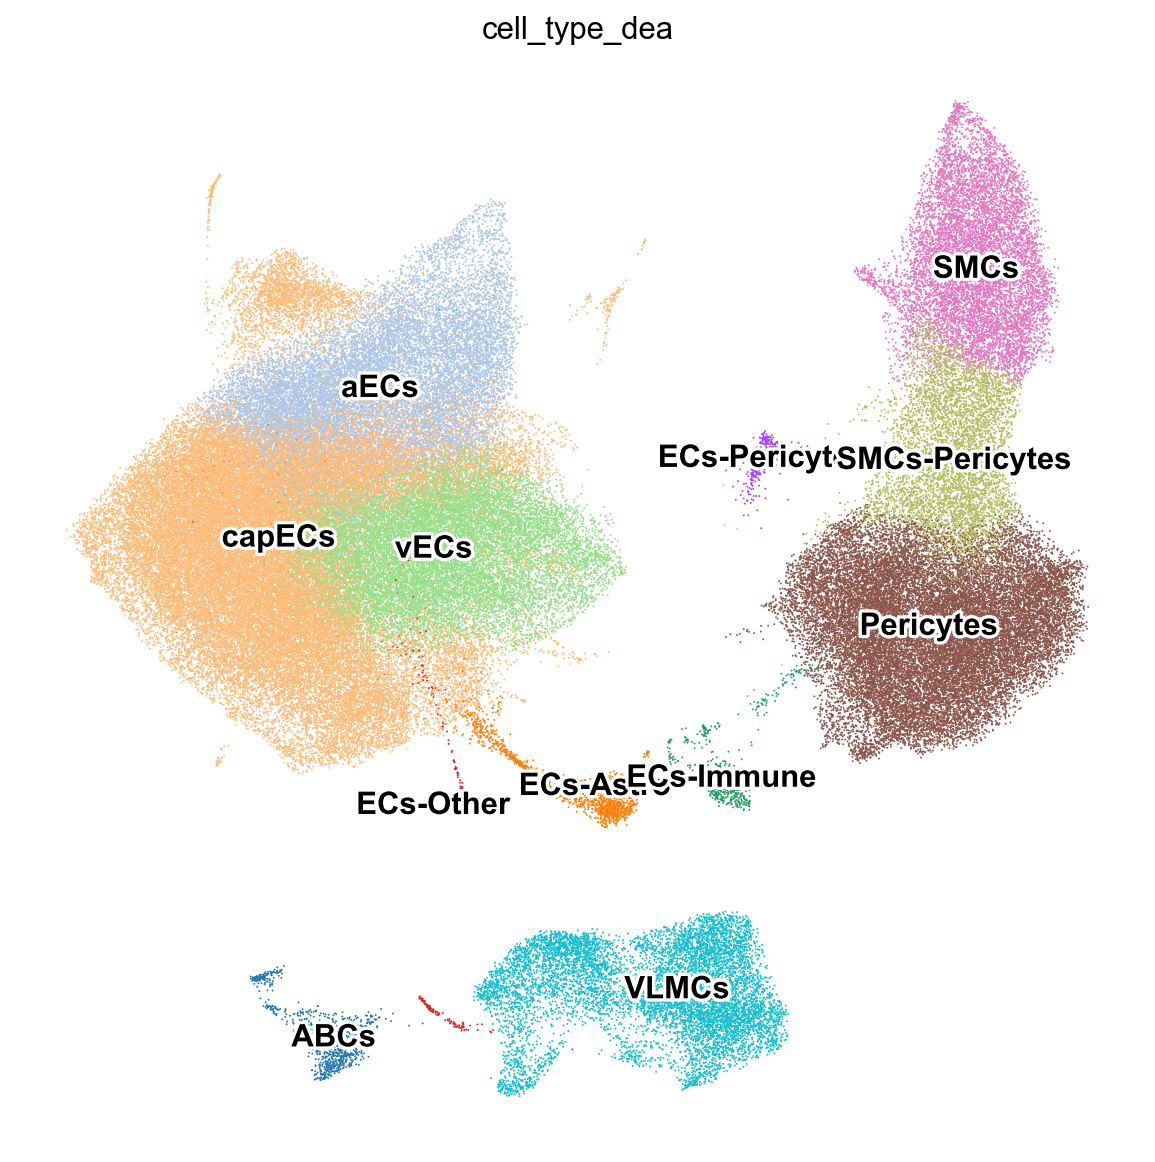

In [83]:
with rc_context({"figure.figsize": (9, 9)}):
    sc.pl.umap(
        adata, color="cell_type_dea", legend_loc="on data", size=3, legend_fontoutline=3
    )

## Pseudobulking

In [84]:
adata.X = adata.layers["counts"]

In [85]:
adata.X.max()

11045.0

In [86]:
adata.obs.head(2)

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id,leiden_res0_05,leiden_res0_1,leiden_res0_2,...,EndMT (EC),EndMT (M),Pan-Ependymal,Ependymocytes cells,Tanycytes,Choroidal epithelial cells,cell_type,celltype_donorid,n_cells,cell_type_dea_previous
TGTGGTATCGGCCGAT-065_C01,WMB-10Xv2-MB-raw,33 Vascular,331 Peri NN,NaN,10Xv2,Pericytes,421226,1,1,1,...,-0.794971,-0.138499,0.008764,0.158495,-0.021304,0.067692,Pericytes,Pericytes_421226,25,Pericytes
GACGGCTCAAACCTAC-059_E01,WMB-10Xv2-MB-raw,33 Vascular,331 Peri NN,NaN,10Xv2,Pericytes,414907,1,1,1,...,-0.747006,-0.059229,0.066743,0.151548,-0.021304,-0.072378,Pericytes,Pericytes_414907,23,Pericytes


In [87]:
adata.obs["cell_type_dea_previous"].value_counts()

ECs          88011
Pericytes    24907
SMCs         14614
VLMCs         9104
ABCs           857
Name: cell_type_dea_previous, dtype: int64

In [88]:
adata.obs["cell_type_dea"].value_counts()

capECs            49337
Pericytes         24362
vECs              19299
aECs              16702
SMCs               9253
VLMCs              8966
SMCs-Pericytes     5778
ECs-Astro          1588
ABCs                874
ECs-Immune          712
ECs-Pericytes       376
ECs-Other           246
Name: cell_type_dea, dtype: int64

In [89]:
for cell_type in adata.obs["cell_type_dea"].cat.categories:
    unique_donors = len(
        adata[adata.obs["cell_type_dea"] == cell_type].obs["donor_id"].cat.categories
    )
    print(f"{unique_donors} {cell_type}")

79 ABCs
105 ECs-Astro
100 ECs-Immune
60 ECs-Other
82 ECs-Pericytes
294 Pericytes
249 SMCs
229 SMCs-Pericytes
271 VLMCs
278 aECs
304 capECs
278 vECs


In [90]:
adata.obs["celltypedea_donorid"] = adata.obs.apply(
    lambda row: f"{row['cell_type_dea']}_{row['donor_id']}", axis=1
)

In [91]:
adata.obs["n_cells"] = adata.obs.groupby(["cell_type_dea", "donor_id"])[
    "donor_id"
].transform("count")

In [92]:
adata.obs[:2]

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id,leiden_res0_05,leiden_res0_1,leiden_res0_2,...,EndMT (M),Pan-Ependymal,Ependymocytes cells,Tanycytes,Choroidal epithelial cells,cell_type,celltype_donorid,n_cells,cell_type_dea_previous,celltypedea_donorid
TGTGGTATCGGCCGAT-065_C01,WMB-10Xv2-MB-raw,33 Vascular,331 Peri NN,NaN,10Xv2,Pericytes,421226,1,1,1,...,-0.138499,0.008764,0.158495,-0.021304,0.067692,Pericytes,Pericytes_421226,25,Pericytes,Pericytes_421226
GACGGCTCAAACCTAC-059_E01,WMB-10Xv2-MB-raw,33 Vascular,331 Peri NN,NaN,10Xv2,Pericytes,414907,1,1,1,...,-0.059229,0.066743,0.151548,-0.021304,-0.072378,Pericytes,Pericytes_414907,23,Pericytes,Pericytes_414907


In [93]:
ncells = adata.obs.groupby(["cell_type_dea", "donor_id"])["n_cells"].count()
ncells = pd.DataFrame(ncells)

In [95]:
adata.obs["cell_type_dea"] = (
    adata.obs["cell_type_dea"]
    .astype(str)
    .str.replace(r"[ /]", "_", regex=True)
    .str.replace(r"[+()]", "", regex=True)
)

In [96]:
adata.obs["donor_id"] = adata.obs["donor_id"].astype("category")
adata.obs["cell_type_dea"] = adata.obs["cell_type_dea"].astype("category")
adata.obs["celltypedea_donorid"] = adata.obs["celltypedea_donorid"].astype("category")
adata.obs["n_cells"] = adata.obs["n_cells"].astype(int)

Pseudobulks per cell type and donor with `cellseg_benchmark.dea_utils.pseudobulk_aggregate_and_filter`, keeping cell type-donor groups with at least `min_cells` cells.

In [97]:
obs_to_keep = [
    "cell_type_dea",
    "donor_id",
    "celltypedea_donorid",
    "n_cells",
    "library_method",
]

In [98]:
min_cells = 16
cell_type_i = adata.obs["cell_type_dea"].cat.categories[0]
print(
    f"Processing {cell_type_i} (1 out of {len(adata.obs['cell_type_dea'].cat.categories)})..."
)
adata_pb = pseudobulk_aggregate_and_filter(
    adata,
    subset_value=cell_type_i,
    subset_key="cell_type_dea",
    sample_key="donor_id",
    min_cells=min_cells,
    obs_to_keep=obs_to_keep,
)
for i, cell_type_i in enumerate(adata.obs["cell_type_dea"].cat.categories[1:]):
    print(
        f"Processing {cell_type_i} ({i + 2} out of {len(adata.obs['cell_type_dea'].cat.categories)})..."
    )
    adata_cell_type = pseudobulk_aggregate_and_filter(
        adata,
        subset_value=cell_type_i,
        subset_key="cell_type_dea",
        sample_key="donor_id",
        min_cells=min_cells,
        obs_to_keep=obs_to_keep,
    )
    adata_pb = adata_pb.concatenate(adata_cell_type)

Processing ABCs (1 out of 12)...
Dropping the following samples:
['352353', '352357', '365619', '366676', '380340', '380345', '381293', '381295', '395345', '404123', '412866', '414905', '414906', '421226', '425676', '426003', '441865', '443005', '443636', '443644', '446701', '446714', '457911', '480180', '507771', '507773', '540566', '546762', '546763', '546799', '546811', '549928', '550468', '550850', '550851', '551017', '551018', '551639', '553672', '553679', '553680', '553682', '554811', '554920', '554922', '556108', '556112', '556113', '556231', '556943', '557213', '560333', '561533', '562458', '562809', '562810', '565823', '565824', '565913', '565914', '566251', '569504', '574608', '619870']
	Processing donor 79 out of 79...

Processing ECs-Astro (2 out of 12)...
Dropping the following samples:
['443005', '469515', '493657', '511243', '532618', '533254', '536273', '536274', '537272', '538745', '539463', '539605', '539606', '540565', '540566', '544398', '544400', '546762', '546763'

In [99]:
adata_pb.obs_names = adata_pb.obs["celltypedea_donorid"]
adata_pb.obs["n_cells"] = adata_pb.obs["n_cells"].astype(int)

In [100]:
adata_pb

AnnData object with n_obs × n_vars = 924 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch'

In [101]:
adata_pb.X.max()

433221.0

In [102]:
pd.crosstab(adata_pb.obs["cell_type_dea"], adata_pb.obs["batch"])

batch,0,1
cell_type_dea,,
ABCs,15,0
ECs-Astro,41,0
ECs-Immune,8,0
ECs-Other,3,0
ECs-Pericytes,4,0
Pericytes,142,0
SMCs,101,0
SMCs-Pericytes,97,0
VLMCs,113,0


## Explore Covariates
on PCA

In [103]:
adata_pb.layers["counts"] = adata_pb.X.copy()
adata_pb.layers["log1p_norm"] = adata_pb.X.copy()
sc.pp.normalize_total(adata_pb, target_sum=1e6, layer="log1p_norm")
sc.pp.log1p(adata_pb, layer="log1p_norm")
adata_pb.X = adata_pb.layers["log1p_norm"]

In [104]:
adata_pb.layers

Layers with keys: counts, log1p_norm

In [105]:
adata_pb.layers["log1p_norm"].max()

11.8260355

In [106]:
adata_pb.layers["counts"].max()

433221.0

In [107]:
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"].astype(np.float64))

In [108]:
adata_pb.obs.head(2)

,cell_type_dea,donor_id,celltypedea_donorid,n_cells,library_method,batch,lib_size,log_lib_size
celltypedea_donorid,,,,,,,,
ABCs_546759,ABCs,546759,ABCs_546759,19,10Xv3,0,256133.0,12.453452
ABCs_546810,ABCs,546810,ABCs_546810,92,10Xv3,0,1354649.0,14.119053


In [109]:
sc.pp.pca(adata_pb)

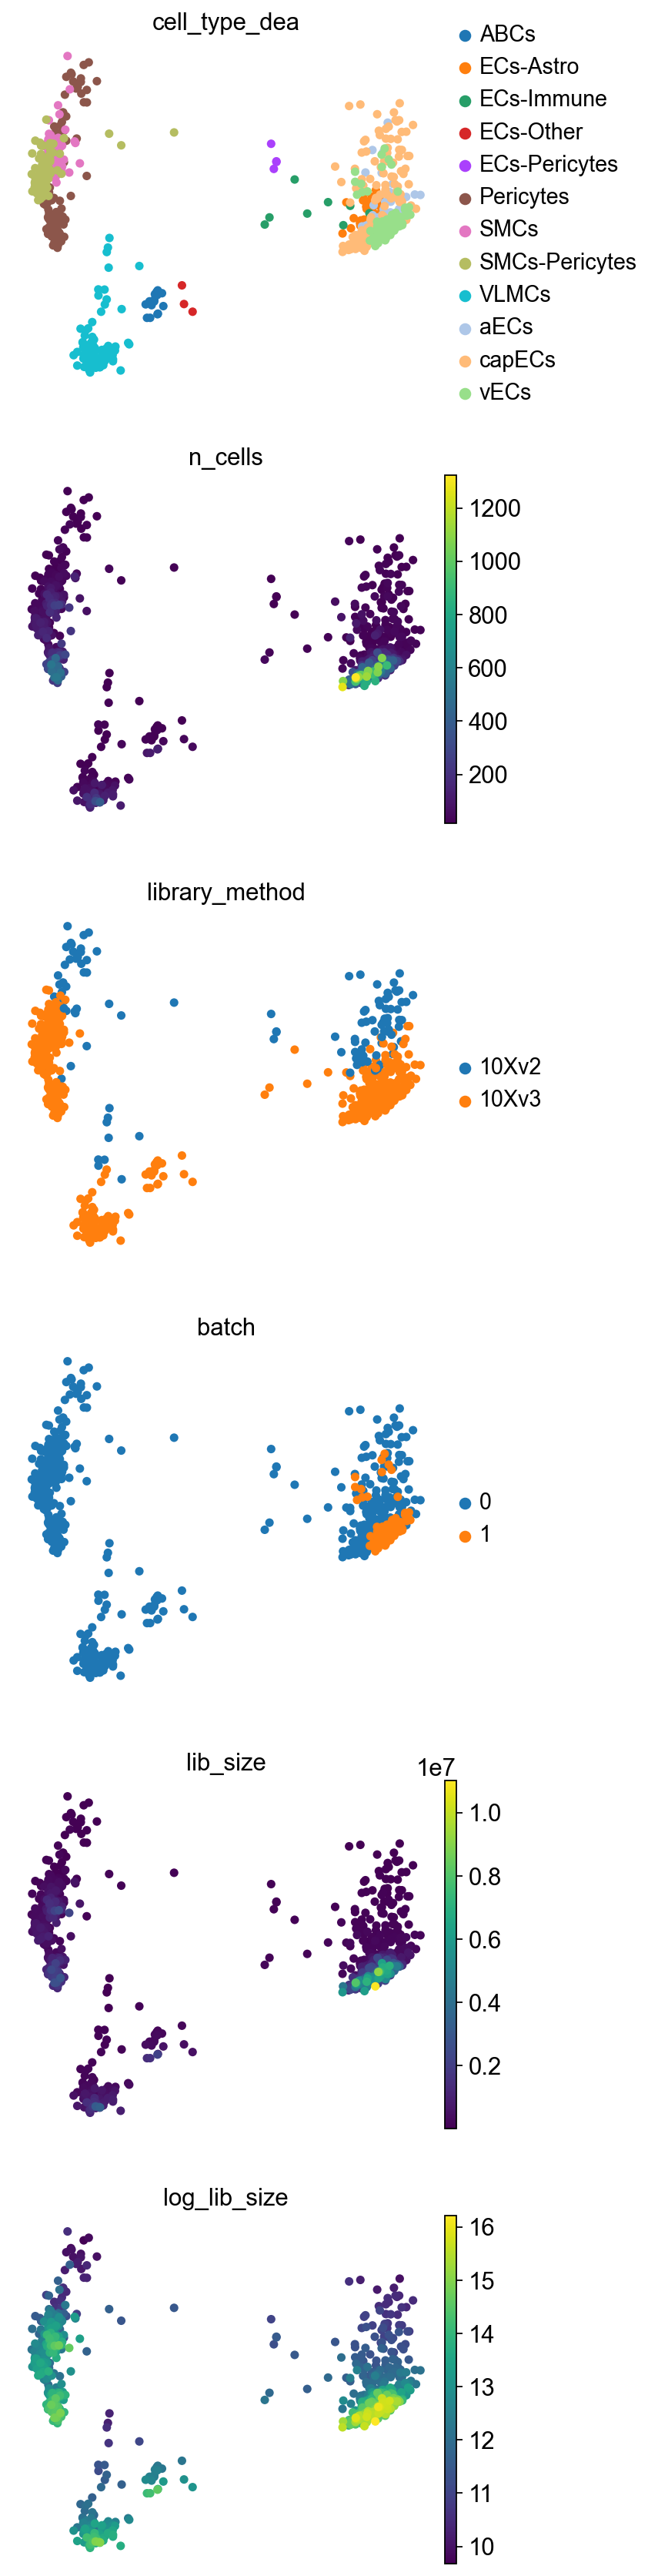

In [110]:
sc.pl.pca(
    adata_pb,
    color=adata_pb.obs.drop(columns=["celltypedea_donorid", "donor_id"]),
    ncols=1,
    size=100,
)

In [111]:
adata_pb.X = adata_pb.layers["counts"].copy()

In [112]:
del adata_pb.layers

In [113]:
del adata_pb.uns["cell_type_dea_colors"]
del adata_pb.uns["batch_colors"]

In [114]:
adata_pb

AnnData object with n_obs × n_vars = 924 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch', 'lib_size', 'log_lib_size'
    uns: 'log1p', 'pca', 'library_method_colors'
    obsm: 'X_pca'
    varm: 'PCs'

In [115]:
adata_pb.obs["lib_size"] = adata_pb.obs["lib_size"].astype(int)
adata_pb.obs["celltypedea_donorid"] = adata_pb.obs["celltypedea_donorid"].astype(
    "category"
)
adata_pb.obs.index = adata_pb.obs["celltypedea_donorid"]

In [116]:
adata_pb.obs.dtypes

cell_type_dea          category
donor_id               category
celltypedea_donorid    category
n_cells                   int64
library_method         category
batch                  category
lib_size                  int64
log_lib_size            float64
dtype: object

In [117]:
adata_pb.X = scipy.sparse.csr_matrix(adata_pb.X, dtype="float32")

In [118]:
adata_pb.X

<924x32285 sparse matrix of type '<class 'numpy.float32'>'
	with 12664148 stored elements in Compressed Sparse Row format>

In [119]:
adata_pb.X.max()

433221.0

In [120]:
adata_pb.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_vascular_subset_pseudobulks.h5ad.gz",
    compression="gzip",
)

In [23]:
setdate = "20250206"  # raw counts, pseudobulks
adata_vascular = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_vascular_subset_pseudobulks.h5ad.gz"
)

In [24]:
adata_vascular

AnnData object with n_obs × n_vars = 924 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch', 'lib_size', 'log_lib_size'
    uns: 'library_method_colors', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [25]:
adata_vascular.X.max()

433221.0

In [27]:
adata_vascular.obs["cell_type_dea"].value_counts()

capECs            171
Pericytes         142
vECs              119
VLMCs             113
aECs              110
SMCs              101
SMCs-Pericytes     97
ECs-Astro          41
ABCs               15
ECs-Immune          8
ECs-Pericytes       4
ECs-Other           3
Name: cell_type_dea, dtype: int64

# Merge pseudobulk datasets

Merge with non-vascular pseudobulk dataset 

In [16]:
setdate = "20250129"  # raw counts, pseudobulks, all merged
adata = sc.read_h5ad(abc_dir / "anndata-objects" / f"{setdate}_pseudobulks_all.h5ad.gz")

In [17]:
adata

AnnData object with n_obs × n_vars = 2743 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch', 'lib_size', 'log_lib_size'
    obsm: 'X_pca'

In [18]:
adata.X.max()

21642372.0

In [21]:
adata = adata[
    ~adata.obs["cell_type_dea"].isin(["Pericytes", "ECs", "VLMCs", "SMCs"])
].copy()

In [22]:
adata

AnnData object with n_obs × n_vars = 2146 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch', 'lib_size', 'log_lib_size'
    obsm: 'X_pca'

In [28]:
adata_vascular

AnnData object with n_obs × n_vars = 924 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch', 'lib_size', 'log_lib_size'
    uns: 'library_method_colors', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [31]:
adata_merged = adata.concatenate(adata_vascular)
adata_merged

AnnData object with n_obs × n_vars = 3070 × 32285
    obs: 'cell_type_dea', 'donor_id', 'celltypedea_donorid', 'n_cells', 'library_method', 'batch', 'lib_size', 'log_lib_size'
    obsm: 'X_pca'

In [37]:
adata_merged.obs.head(2)

,cell_type_dea,donor_id,celltypedea_donorid,n_cells,library_method,batch,lib_size,log_lib_size
celltypedea_donorid,,,,,,,,
Astrocytes_352353-0,Astrocytes,352353,Astrocytes_352353,142,10Xv2,0,434153,12.981152
Astrocytes_352356-0,Astrocytes,352356,Astrocytes_352356,174,10Xv2,0,608173,13.318215


In [40]:
adata_merged.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_pseudobulks_all_inclzonation.h5ad.gz",
    compression="gzip",
)